In [1]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from dust_extinction.parameter_averages import G23
import astropy.units as u

### Simple way to initiate the dust corrector and get the band transmissions and wavelengths
```python
from superbit_lensing.dust import DustCorrector
dust = DustCorrector()
```

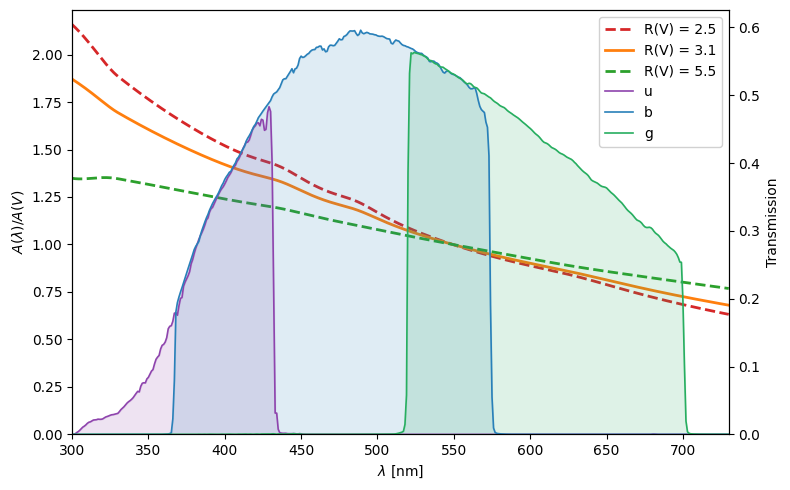

In [2]:
## Simple way to initiate the dust corrector and get the band transmissions and wavelengths
from superbit_lensing.dust import DustCorrector
dust = DustCorrector()
u_transmission = dust._get_band_transmission('u')
b_transmission = dust._get_band_transmission('b')
g_transmission = dust._get_band_transmission('g')
wavelengths =  dust.wavelengths.value

fig, ax1 = plt.subplots(figsize=(8, 5))

# --- Extinction curves (left y-axis) ---
lam = np.logspace(np.log10(0.3), np.log10(0.730), num=500) * u.micron
lam_nm = lam.to(u.nm).value

Rvs = [2.5, 3.1, 5.5]
ext_colors = ['#d62728', '#ff7f0e', '#2ca02c'] 
ext_styles = ['--', '-', '--']

for cur_Rv, c, ls in zip(Rvs, ext_colors, ext_styles):
    ext_model = G23(Rv=cur_Rv)
    ax1.plot(lam_nm, ext_model(lam), color=c, linestyle=ls, linewidth=2, label=f'R(V) = {cur_Rv}')

ax1.set_xlabel(r'$\lambda$ [nm]')
ax1.set_ylabel(r'$A(\lambda)/A(V)$')
ax1.set_xlim(300, 730)

# --- Filter transmissions (right y-axis, shared x) ---
ax2 = ax1.twinx()

mask = wavelengths <= 730
filter_info = [
    (u_transmission, '#8E44AD', 'u'),
    (b_transmission, '#2980B9', 'b'), 
    (g_transmission, '#27AE60', 'g'),    
]

for transmission, color, label in filter_info:
    ax2.fill_between(wavelengths[mask], transmission[mask], alpha=0.15, color=color)
    ax2.plot(wavelengths[mask], transmission[mask], color=color, linewidth=1.2, label=label)

ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax2.set_ylabel('Transmission')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

### The $A(\lambda)/A(V)$ for a given band should be a weighted average with transmission as the weight
$$
\left\langle \frac{A_\lambda}{A_V} \right\rangle_{\rm band} = 
\frac{\displaystyle\int T_ {\rm band} (\lambda)\;\frac{A_\lambda}{A_V}\;\lambda\;\mathrm{d}\lambda}
     {\displaystyle\int T_ {\rm band} (\lambda)\;\lambda\;\mathrm{d}\lambda}$$

Those values for the superBIT bands can be obtained as follows:

In [3]:
AxAv_u = dust._compute_band_AxAv('u')
AxAv_b = dust._compute_band_AxAv('b')
AxAv_g = dust._compute_band_AxAv('g')
print(f"AxAV (u band) = {AxAv_u:.3f}")
print(f"AxAV (b band) = {AxAv_b:.3f}")
print(f"AxAV (g band) = {AxAv_g:.3f}")

AxAV (u band) = 1.437
AxAV (b band) = 1.180
AxAV (g band) = 0.900


Whereas if we just use pivot wavelengths for u (400 nm), b (480 nm), g (600 nm), we get the following values:

In [4]:
print(f"AxAV (u band at 400 nm) = {dust.model(400 * u.nm):.3f}")
print(f"AxAV (b band at 480 nm) = {dust.model(480 * u.nm):.3f}")
print(f"AxAV (g band at 600 nm) = {dust.model(600 * u.nm):.3f}")

AxAV (u band at 400 nm) = 1.421
AxAV (b band at 480 nm) = 1.198
AxAV (g band at 600 nm) = 0.901


In [5]:
fname = "demo_Abell1689.fits"
tab = Table.read(fname)

ra = tab['ra']
dec = tab['dec']
dust = DustCorrector()
Ax = dust(ra, dec)

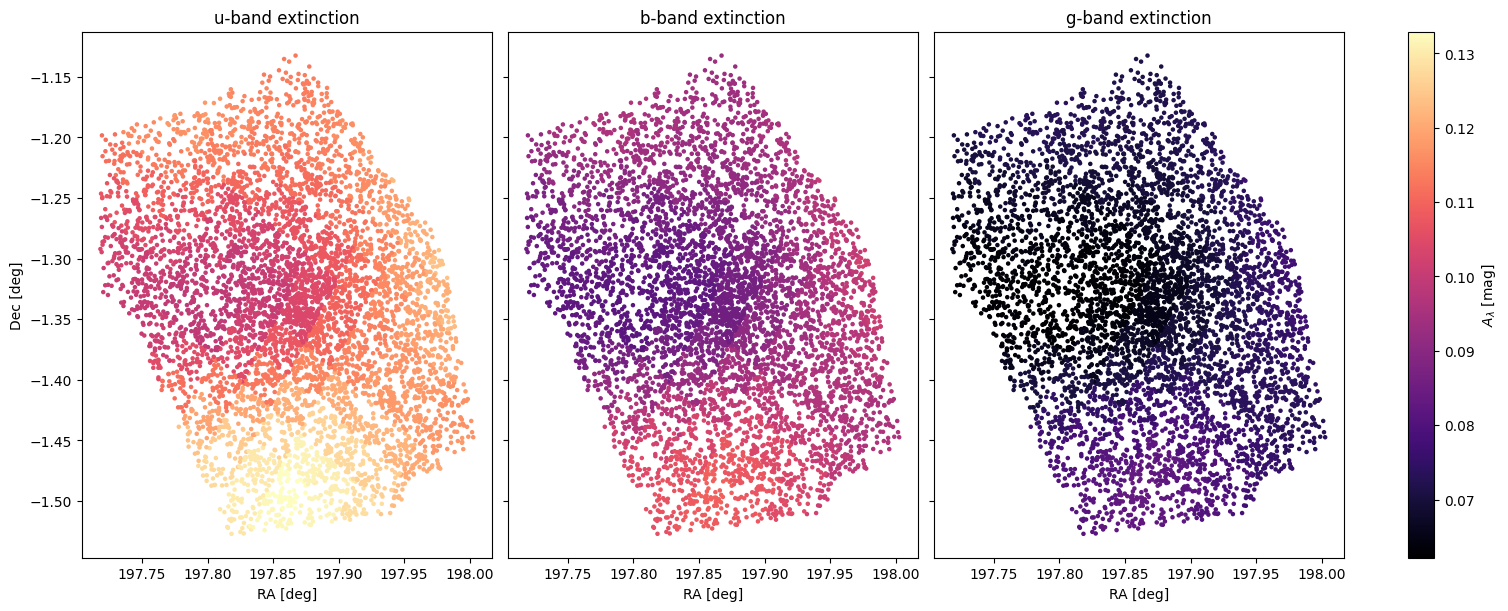

In [6]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True   
)

bands = ['u', 'b', 'g']

# --- global color scale ---
all_vals = np.concatenate([Ax[b] for b in bands])
vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

norm = Normalize(vmin=vmin, vmax=vmax)

# --- scatter plots ---
for i, (ax, band) in enumerate(zip(axes, bands)):
    sc = ax.scatter(
        ra, dec,
        c=Ax[band],
        s=5,
        cmap='magma',
        norm=norm
    )

    ax.set_title(f'{band}-band extinction')
    ax.set_xlabel('RA [deg]')

    if i == 0:
        ax.set_ylabel('Dec [deg]')
    else:
        ax.set_ylabel('')   

# --- shared colorbar ---
sm = ScalarMappable(norm=norm, cmap='magma')
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel(),   
    location='right',
    shrink=1.0
)

cbar.set_label(r'$A_\lambda$ [mag]')

plt.show()
plt.close('all')

In [7]:
def generate_uniform_sky(n_points):
    # RA uniform
    ra = np.random.uniform(0, 360, n_points)

    # Dec: uniform in sin(dec)
    u = np.random.uniform(-1, 1, n_points)
    dec = np.degrees(np.arcsin(u))

    return ra, dec

n_points = 5000000

ra, dec = generate_uniform_sky(n_points)

dust = DustCorrector()
Ax = dust(ra, dec)   # dict: u, b, g

In [8]:
data = np.load("galactic_coords.npz")
l_rad_shift = data["l_rad_shift"]
b_rad = data["b_rad"]

# undo shift and convert back to degrees
l = np.degrees(l_rad_shift) + 180.0
b = np.degrees(b_rad)

# wrap l into [0, 360]
l = np.mod(l, 360.0)

In [9]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

nside = 128
npix = hp.nside2npix(nside)

# convert (RA, Dec) → (theta, phi)
theta = np.radians(90.0 - dec)
phi = np.radians(ra)

pix = hp.ang2pix(nside, theta, phi)

bands = ['u', 'b', 'g']
titles = {'u': 'SuperBIT u', 'b': 'SuperBIT b', 'g': 'SuperBIT g'}

# --- compute maps for each band ---
maps = {}

for band in bands:
    values = np.zeros(npix)
    counts = np.zeros(npix)

    for i in range(len(pix)):
        values[pix[i]] += Ax[band][i]
        counts[pix[i]] += 1

    hp_map = np.full(npix, np.nan)
    mask = counts > 0
    hp_map[mask] = values[mask] / counts[mask]

    maps[band] = hp_map

# --- global color scale (important!) ---
all_vals = np.concatenate([maps[b][~np.isnan(maps[b])] for b in bands])

vmin = 0.01
vmax = np.percentile(all_vals, 99)  # robust upper limit

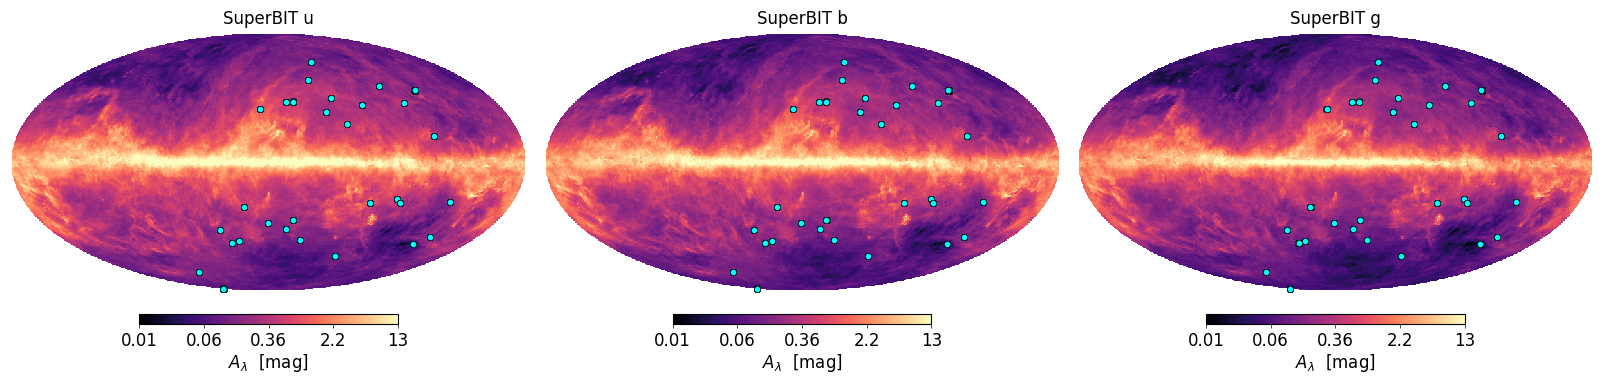

In [10]:
nticks = 5
plt.figure(figsize=(16, 4.5))
fig = plt.gcf()

ticks = np.logspace(np.log10(vmin), np.log10(vmax), nticks)

for i, band in enumerate(bands, 1):
    hp.mollview(
        maps[band],
        coord=['C', 'G'],
        title=titles[band],
        unit="",
        min=vmin,
        max=vmax,
        cmap="magma",
        norm='log10',
        notext=True,
        sub=(1, 3, i)
    )
    
    hp.projscatter(
        l, b,
        lonlat=True, 
        s=20,
        c='cyan',
        edgecolors='k',
        linewidth=0.5,
        alpha=0.8,
        zorder=5
    )

    cb_ax = fig.get_axes()[-1]
    cb_ax.set_xticks(ticks)
    cb_ax.set_xticklabels([f'{t:.2g}' for t in ticks], fontsize=12)
    cb_ax.set_xlabel(r"$A_\lambda$  [mag]", fontsize=12, labelpad=2)
    cb_ax.tick_params(length=3, width=0.5, pad=2)

plt.subplots_adjust(wspace=0.15)
#plt.savefig("superbit_extinction_maps.pdf", dpi=200, bbox_inches='tight', pad_inches=0.1)
plt.show()